### Step 1: Set Up Google Colab & Download Data

In [1]:
# 1. Download dataset directly via kagglehub/gdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset (using standard public credit card fraud data)
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
df = pd.read_csv(url)

print(f"Dataset Shape: {df.shape}")
print("\nTarget Class Distribution (0 = Legitimate, 1 = Fraudulent):")
print(df['Class'].value_counts(normalize=True))

df.head()

Dataset Shape: (284807, 31)

Target Class Distribution (0 = Legitimate, 1 = Fraudulent):
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Step 2: Data Exploration & Feature Scaling

1. Data cleaning & sanity audit

In [4]:
# 1. Check for Missing Values across all features
missing_values = df.isnull().sum().sum()
print(f"Total Missing Values: {missing_values}")

# 2. Check for Duplicate Records
duplicate_count = df.duplicated().sum()
print(f"Total Duplicate Rows Found: {duplicate_count}")

# 3. Handle Duplicates (Drop exact duplicate transactions to prevent data leakage)
if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print(f"Duplicates removed. Updated Dataset Shape: {df.shape}")

Total Missing Values: 0
Total Duplicate Rows Found: 1081
Duplicates removed. Updated Dataset Shape: (283726, 31)


2. EDA

/tmp/ipykernel_2673/93758659.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=feature, data=df, palette=['#2b5c8f', '#d9534f'])
/tmp/ipykernel_2673/93758659.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=feature, data=df, palette=['#2b5c8f', '#d9534f'])
/tmp/ipykernel_2673/93758659.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=feature, data=df, palette=['#2b5c8f', '#d9534f'])
/tmp/ipykernel_2673/93758659.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and wil

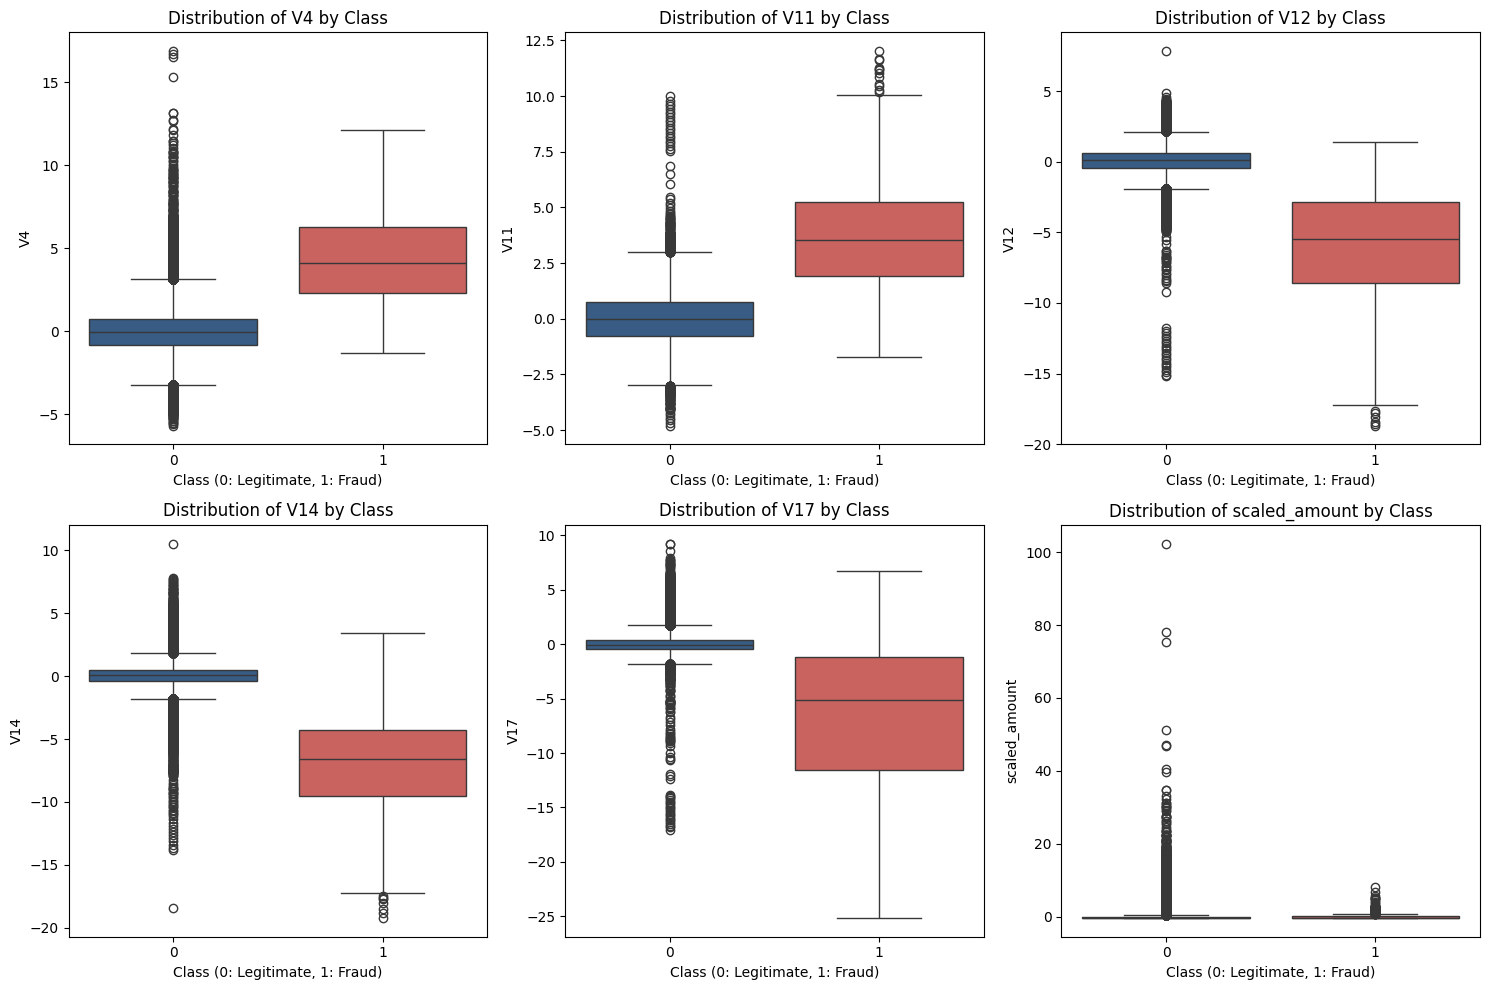

In [5]:
# Plot feature distribution comparisons for top differentiating PCA features
features_to_plot = ['V4', 'V11', 'V12', 'V14', 'V17', 'scaled_amount']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='Class', y=feature, data=df, palette=['#2b5c8f', '#d9534f'])
    plt.title(f'Distribution of {feature} by Class')
    plt.xlabel('Class (0: Legitimate, 1: Fraud)')

plt.tight_layout()
plt.show()

Total Transactions: 284,807
Fraudulent Transactions: 492 (0.173%)


/tmp/ipykernel_2673/675351098.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette=['#2b5c8f', '#d9534f'])


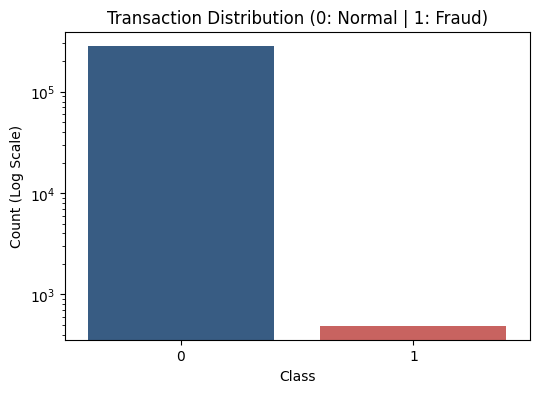

In [2]:
from sklearn.preprocessing import StandardScaler

# 1. Scale 'Amount' and 'Time' using StandardScaler to match PCA features
scaler = StandardScaler()
df['scaled_amount'] = scaler.fit_transform(df[['Amount']])
df['scaled_time'] = scaler.fit_transform(df[['Time']])

# Drop original unscaled columns
df.drop(columns=['Amount', 'Time'], inplace=True)

# 2. Inspect target class imbalance
fraud_count = df['Class'].sum()
total_count = len(df)
fraud_percentage = (fraud_count / total_count) * 100

print(f"Total Transactions: {total_count:,}")
print(f"Fraudulent Transactions: {fraud_count:,} ({fraud_percentage:.3f}%)")

# Visualize Class Imbalance
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df, palette=['#2b5c8f', '#d9534f'])
plt.title('Transaction Distribution (0: Normal | 1: Fraud)')
plt.yscale('log') # Log scale due to extreme imbalance
plt.ylabel('Count (Log Scale)')
plt.show()

3. Compare Legitimate vs. Fraudulent Amount

In [3]:
# Summary statistics for transaction amounts across classes
print("Legitimate Transactions (Class 0):")
print(df[df['Class'] == 0]['scaled_amount'].describe())

print("\nFraudulent Transactions (Class 1):")
print(df[df['Class'] == 1]['scaled_amount'].describe())

Legitimate Transactions (Class 0):
count    284315.000000
mean         -0.000234
std           0.999942
min          -0.353229
25%          -0.330640
50%          -0.265271
75%          -0.045177
max         102.362243
Name: scaled_amount, dtype: float64

Fraudulent Transactions (Class 1):
count    492.000000
mean       0.135382
std        1.026242
min       -0.353229
25%       -0.349231
50%       -0.316247
75%        0.070128
max        8.146182
Name: scaled_amount, dtype: float64


### Step 3: Handling Class Imbalance, Model Training and Comparison

1. Stratified Train-Test Split

Because fraud represents less than 0.2% of transactions, we must use a **Stratified Split** to ensure both training and test sets maintain the exact same fraud ratio.

In [6]:
from sklearn.model_selection import train_test_split

# Define Features (X) and Target (y)
X = df.drop(columns=['Class'])
y = df['Class']

# Stratified Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training Set: {X_train.shape[0]:,} samples | Fraud Ratio: {y_train.mean():.4%}")
print(f"Testing Set:  {X_test.shape[0]:,} samples  | Fraud Ratio: {y_test.mean():.4%}")

Training Set: 226,980 samples | Fraud Ratio: 0.1665%
Testing Set:  56,746 samples  | Fraud Ratio: 0.1674%


2. Train Isolation Forest (Baseline Anomaly Engine)

Isolation Forest explicitly isolates anomalies by randomly selecting a feature and splitting the data. Anomalies require fewer splits to isolate than normal points.

In [7]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

# Contamination set to match approximate fraud ratio
iso_forest = IsolationForest(contamination=0.0017, random_state=42, n_jobs=-1)
iso_forest.fit(X_train)

# Isolation Forest outputs 1 for normal, -1 for anomaly -> Convert to 0 for normal, 1 for fraud
y_pred_iso_raw = iso_forest.predict(X_test)
y_pred_iso = np.where(y_pred_iso_raw == -1, 1, 0)
iso_scores = -iso_forest.decision_function(X_test)  # Higher score = more anomalous

print("--- Isolation Forest (Unsupervised) Performance ---")
print(classification_report(y_test, y_pred_iso, target_names=['Legitimate', 'Fraud']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, iso_scores):.4f}")
print(f"PR-AUC Score (Average Precision): {average_precision_score(y_test, iso_scores):.4f}")

--- Isolation Forest (Unsupervised) Performance ---
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.24      0.25      0.24        95

    accuracy                           1.00     56746
   macro avg       0.62      0.63      0.62     56746
weighted avg       1.00      1.00      1.00     56746

ROC-AUC Score: 0.9404
PR-AUC Score (Average Precision): 0.1545


3. Train XGBoost Fraud Classifier

Now we train a supervised **XGBoost Classifier** using `scale_pos_weight` to compensate for the heavy 1:580 class imbalance.

In [8]:
import xgboost as xgb

# Calculate scale_pos_weight = (Number of negative samples / Number of positive samples)
scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

# Initialize and train XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

# Predict probabilities and hard labels on Test set
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_prob_xgb >= 0.5).astype(int)

print("--- XGBoost Classifier (Supervised) Performance ---")
print(classification_report(y_test, y_pred_xgb, target_names=['Legitimate', 'Fraud']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(f"PR-AUC Score (Average Precision): {average_precision_score(y_test, y_prob_xgb):.4f}")

--- XGBoost Classifier (Supervised) Performance ---
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.64      0.79      0.70        95

    accuracy                           1.00     56746
   macro avg       0.82      0.89      0.85     56746
weighted avg       1.00      1.00      1.00     56746

ROC-AUC Score: 0.9684
PR-AUC Score (Average Precision): 0.8022


### Step 4: Precision-Recall Evaluation & Threshold Tuning

In digital banking fraud detection, standard model accuracy is a misleading metric. Instead, risk operations teams manage a strict trade-off:
- High Recall (Catching all fraud): Protects the bank from financial loss, but risks flagging innocent transactions and annoying customers.
- High Precision (Only flagging high-confidence fraud): Keeps legitimate transactions flowing smoothly, but risks letting actual fraud bypass the system.

1. Plot Confusion Matrix & Precision-Recall Curve

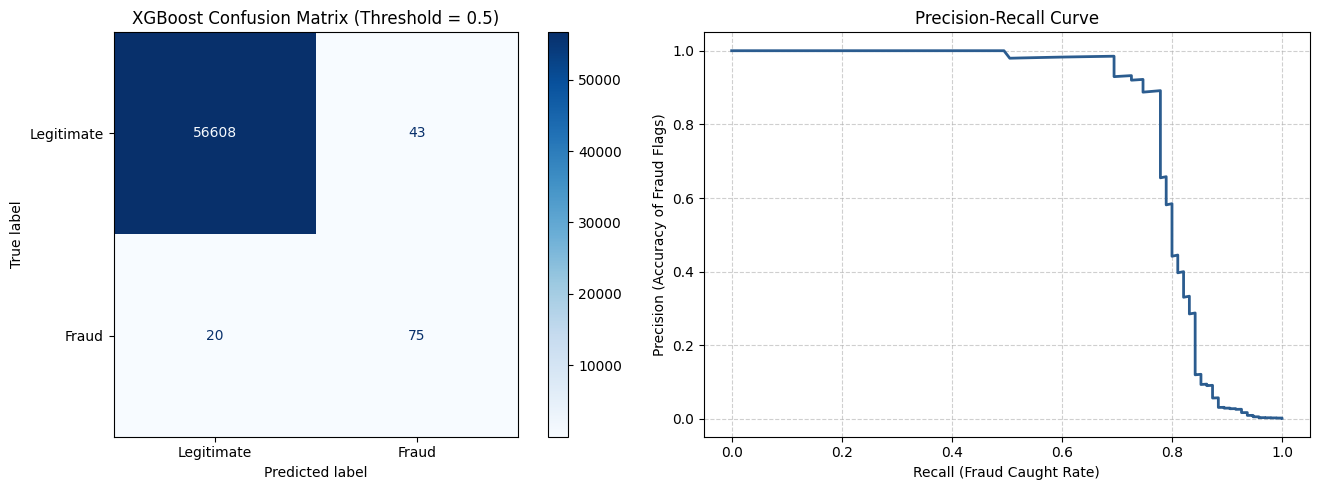

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# 1. Confusion Matrix Plot
cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate', 'Fraud'])
disp.plot(cmap='Blues', ax=ax[0])
ax[0].set_title("XGBoost Confusion Matrix (Threshold = 0.5)")

# 2. Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_xgb)
ax[1].plot(recall, precision, color='#2b5c8f', lw=2)
ax[1].set_xlabel("Recall (Fraud Caught Rate)")
ax[1].set_ylabel("Precision (Accuracy of Fraud Flags)")
ax[1].set_title("Precision-Recall Curve")
ax[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

2. Decision Threshold Tuning for Risk Operations

In practice, digital banks rarely use a fixed `0.5` probability threshold. By tuning the cutoff threshold, we can optimize the operational balance between customer experience and financial loss mitigation.

In [10]:
# Analyze performance across custom risk thresholds
threshold_levels = [0.1, 0.3, 0.5, 0.7, 0.9]
results = []

for th in threshold_levels:
    y_custom_pred = (y_prob_xgb >= th).astype(int)
    cm_temp = confusion_matrix(y_test, y_custom_pred)
    tn, fp, fn, tp = cm_temp.ravel()

    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0

    results.append({
        'Risk Threshold': th,
        'Caught Fraud (TP)': tp,
        'Missed Fraud (FN)': fn,
        'False Alarms (FP)': fp,
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4)
    })

threshold_df = pd.DataFrame(results)
print("--- Threshold Optimization Matrix ---")
display(threshold_df)

--- Threshold Optimization Matrix ---


,Risk Threshold,Caught Fraud (TP),Missed Fraud (FN),False Alarms (FP),Precision,Recall,F1-Score
0,0.1,80,15,366,0.1794,0.8421,0.2957
1,0.3,77,18,101,0.4326,0.8105,0.5641
2,0.5,75,20,43,0.6356,0.7895,0.7042
3,0.7,74,21,22,0.7708,0.7789,0.7749
4,0.9,74,21,10,0.8810,0.7789,0.8268


### Step 5: Model Explainability with SHAP

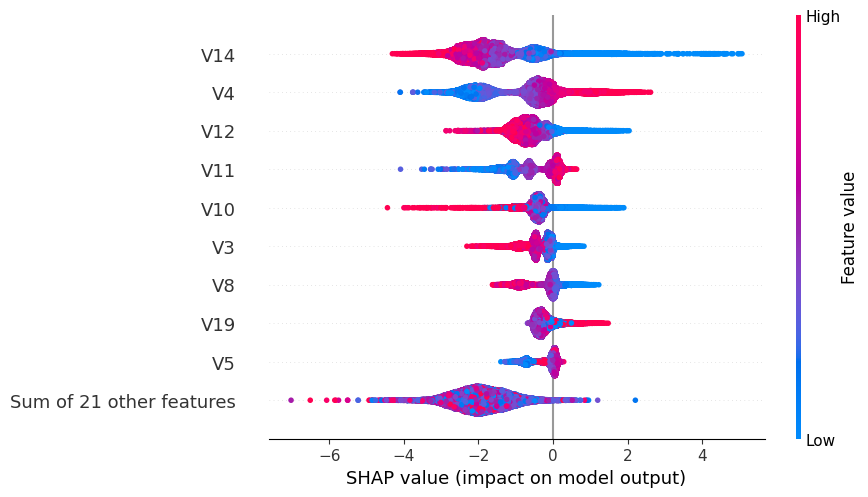

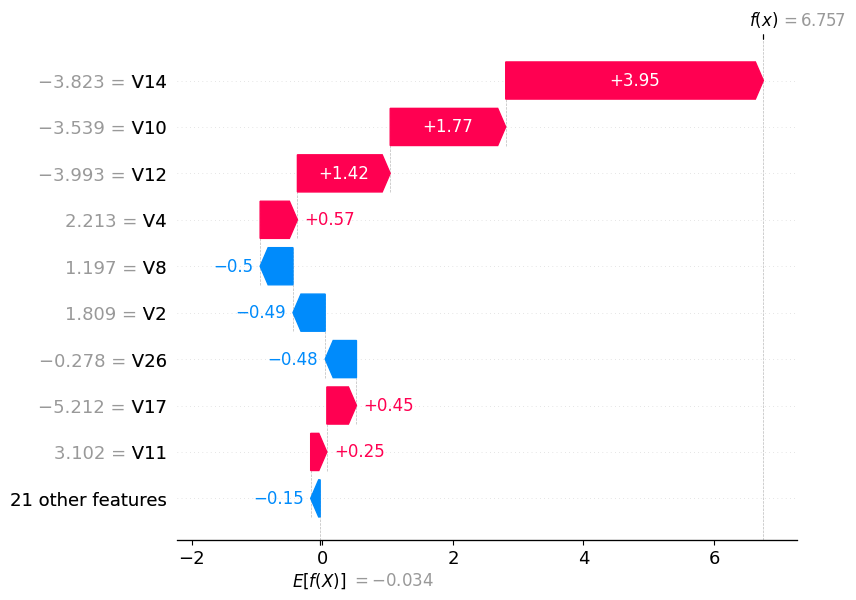

In [11]:
import shap

# Initialize SHAP TreeExplainer on the trained XGBoost model
explainer = shap.TreeExplainer(xgb_model)
shap_explanation = explainer(X_test)

# 1. Global SHAP Beeswarm Plot (Top fraud indicators across all transactions)
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_explanation, max_display=10)

# 2. Local Waterfall Plot for a single detected fraud case
# Find the first index where actual class is Fraud (1)
fraud_indices = np.where(y_test == 1)[0]
first_fraud_idx = fraud_indices[0]

plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_explanation[first_fraud_idx], max_display=10)

### Step 6: Deployment

This code builds an interactive monitoring dashboard where fraud analysts can adjust risk thresholds in real time and test specific transaction profiles.

In [12]:
import os
os.makedirs("app", exist_ok=True)